# Exploratory Data Analysis (EDA)
## Museum Visitor Prediction — Melbourne Museum of Migration

This notebook explores patterns, distributions, and relationships in the simulated visitor dataset to guide feature engineering and model selection.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Load data
df = pd.read_csv('../data/raw/museum_visitors_melbourne.csv', parse_dates=['date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (1096, 26)
Date range: 2023-01-01 to 2025-12-31

Columns: ['date', 'year', 'month', 'day', 'day_of_week', 'day_name', 'week_of_year', 'quarter', 'is_public_holiday', 'is_school_holiday', 'temperature', 'precipitation', 'weather_type', 'special_exhibition', 'local_event', 'marketing_campaign', 'ticket_promotion', 'ticket_price', 'visitors_last_week', 'visitors_last_2weeks', 'visitors_last_month', 'visitors_7day_avg', 'visitors_14day_avg', 'visitors_30day_avg', 'visitors_same_day_last_year', 'visitors']


## 1. Dataset Overview

In [3]:
df.head(10)

,date,year,month,day,day_of_week,day_name,week_of_year,quarter,is_public_holiday,is_school_holiday,temperature,precipitation,weather_type,special_exhibition,local_event,marketing_campaign,ticket_promotion,ticket_price,visitors_last_week,visitors_last_2weeks,visitors_last_month,visitors_7day_avg,visitors_14day_avg,visitors_30day_avg,visitors_same_day_last_year,visitors
0,2023-01-01,2023,1,1,6,Sunday,52,1,1,0,20.6,0.7,Cloudy,0,0,1,0,25,381.698806,380.627542,379.10788,931.000000,931.000000,931.000000,380.942544,931
1,2023-01-02,2023,1,2,0,Monday,1,1,1,0,21.7,1.5,Cloudy,0,0,0,0,25,381.698806,380.627542,379.10788,677.000000,677.000000,677.000000,380.942544,423
2,2023-01-03,2023,1,3,1,Tuesday,1,1,0,0,14.2,2.4,Cloudy,0,0,0,0,25,381.698806,380.627542,379.10788,523.333333,523.333333,523.333333,380.942544,216
3,2023-01-04,2023,1,4,2,Wednesday,1,1,0,0,17.4,4.6,Cloudy,0,0,0,0,25,381.698806,380.627542,379.10788,460.500000,460.500000,460.500000,380.942544,272
4,2023-01-05,2023,1,5,3,Thursday,1,1,0,0,18.6,3.1,Cloudy,0,0,0,0,25,381.698806,380.627542,379.10788,417.600000,417.600000,417.600000,380.942544,246
5,2023-01-06,2023,1,6,4,Friday,1,1,0,0,18.9,2.3,Cloudy,0,0,1,1,20,381.698806,380.627542,379.10788,420.666667,420.666667,420.666667,380.942544,436
6,2023-01-07,2023,1,7,5,Saturday,1,1,0,0,26.9,2.3,Cloudy,0,0,0,0,25,381.698806,380.627542,379.10788,426.142857,426.142857,426.142857,380.942544,459
7,2023-01-08,2023,1,8,6,Sunday,1,1,0,0,23.3,5.8,Rainy,0,0,0,0,25,931.000000,380.627542,379.10788,338.142857,412.250000,412.250000,380.942544,315
8,2023-01-09,2023,1,9,0,Monday,2,1,0,0,14.9,0.7,Cloudy,0,0,0,0,25,423.000000,380.627542,379.10788,313.142857,394.000000,394.000000,380.942544,248
9,2023-01-10,2023,1,10,1,Tuesday,2,1,0,0,21.7,0.0,Sunny,0,0,0,0,25,216.000000,380.627542,379.10788,341.428571,396.000000,396.000000,380.942544,414


In [4]:
df.describe().round(2)

,date,year,month,day,day_of_week,week_of_year,quarter,is_public_holiday,is_school_holiday,temperature,precipitation,special_exhibition,local_event,marketing_campaign,ticket_promotion,ticket_price,visitors_last_week,visitors_last_2weeks,visitors_last_month,visitors_7day_avg,visitors_14day_avg,visitors_30day_avg,visitors_same_day_last_year,visitors
count,1096,1096.00,1096.00,1096.00,1096.0,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096.0,1096.0,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00
mean,2024-07-01 12:00:00,2024.00,6.52,15.73,3.0,26.45,2.51,0.03,0.18,15.10,1.95,0.67,0.07,0.16,0.1,24.5,381.70,380.63,379.11,383.41,382.93,382.06,380.94,383.07
min,2023-01-01 00:00:00,2023.00,1.00,1.00,0.0,1.00,1.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00,0.0,20.0,109.00,109.00,109.00,183.86,202.79,209.70,109.00,109.00
25%,2023-10-01 18:00:00,2023.00,4.00,8.00,1.0,13.00,2.00,0.00,0.00,10.90,0.60,0.00,0.00,0.00,0.0,25.0,264.00,264.00,264.00,285.96,283.18,289.81,309.00,264.00
50%,2024-07-01 12:00:00,2024.00,7.00,16.00,3.0,26.00,3.00,0.00,0.00,14.50,1.35,1.00,0.00,0.00,0.0,25.0,348.00,348.00,350.00,384.93,397.00,412.35,380.94,348.00
75%,2025-04-01 06:00:00,2025.00,10.00,23.00,5.0,39.25,4.00,0.00,0.00,18.70,2.70,1.00,0.00,0.00,0.0,25.0,464.00,459.50,457.00,472.04,465.00,463.63,395.00,465.00
max,2025-12-31 00:00:00,2025.00,12.00,31.00,6.0,52.00,4.00,1.00,1.00,40.10,12.20,1.00,1.00,1.00,1.0,25.0,1200.00,1200.00,1200.00,931.00,931.00,931.00,1200.00,1200.00
std,NaN,0.82,3.45,8.81,2.0,15.07,1.12,0.18,0.38,5.55,1.92,0.47,0.25,0.37,0.3,1.5,164.62,163.84,162.19,113.39,105.55,97.12,140.41,165.74


In [5]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

print("\nData types:")
print(df.dtypes)

Missing values per column:
No missing values found.

Data types:
date                           datetime64[ns]
year                                    int64
month                                   int64
day                                     int64
day_of_week                             int64
day_name                               object
week_of_year                            int64
quarter                                 int64
is_public_holiday                       int64
is_school_holiday                       int64
temperature                           float64
precipitation                         float64
weather_type                           object
special_exhibition                      int64
local_event                             int64
marketing_campaign                      int64
ticket_promotion                        int64
ticket_price                            int64
visitors_last_week                    float64
visitors_last_2weeks                  float64
visitors_last_m

## 2. Target Variable — Visitor Distribution

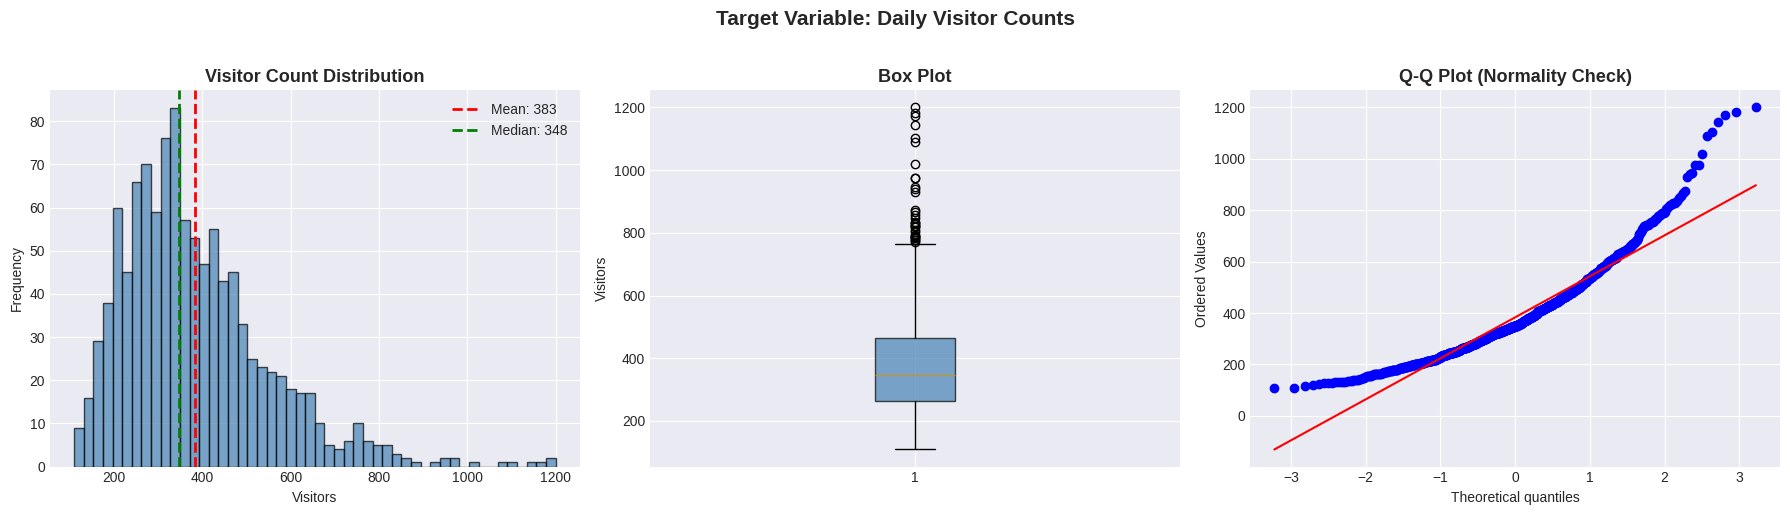

Skewness: 1.264
Kurtosis: 2.533


In [6]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['visitors'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['visitors'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['visitors'].mean():.0f}")
axes[0].axvline(df['visitors'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {df['visitors'].median():.0f}")
axes[0].set_title('Visitor Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Visitors')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['visitors'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Visitors')

# Q-Q plot
stats.probplot(df['visitors'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Daily Visitor Counts', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness: {df['visitors'].skew():.3f}")
print(f"Kurtosis: {df['visitors'].kurt():.3f}")

## 3. Time Series Analysis

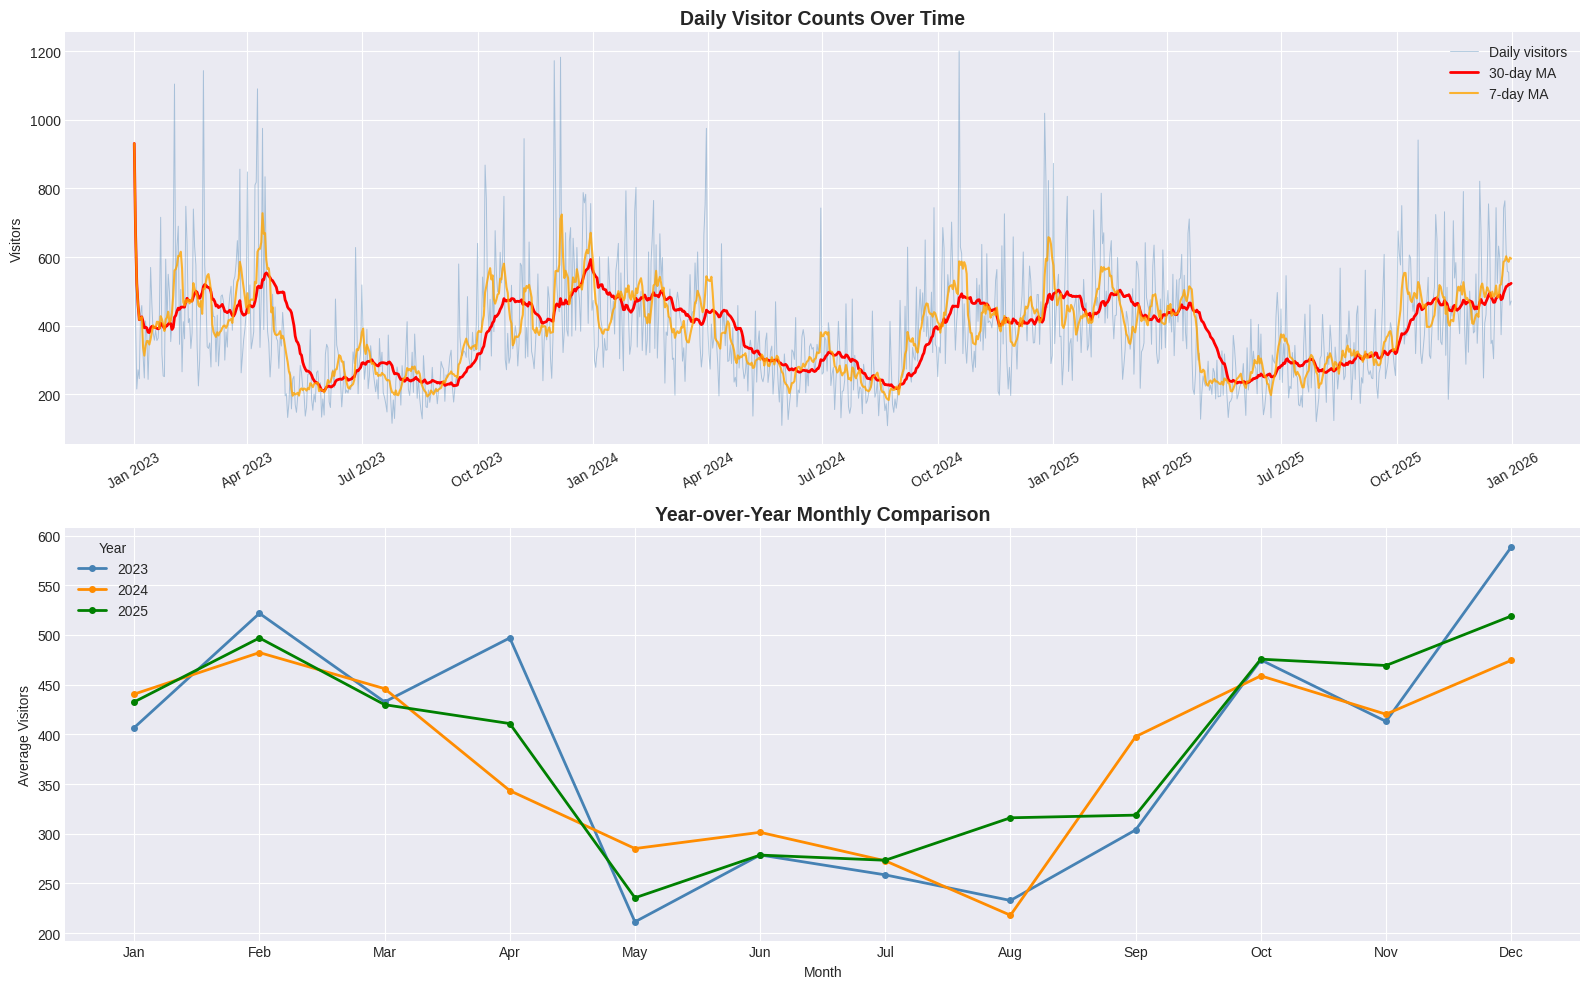

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full time series
axes[0].plot(df['date'], df['visitors'], alpha=0.4, linewidth=0.7, color='steelblue', label='Daily visitors')
axes[0].plot(df['date'], df['visitors_30day_avg'], color='red', linewidth=2, label='30-day MA')
axes[0].plot(df['date'], df['visitors_7day_avg'], color='orange', linewidth=1.5, alpha=0.8, label='7-day MA')
axes[0].set_title('Daily Visitor Counts Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Visitors')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Year-over-year monthly comparison
for year, color in zip([2023, 2024, 2025], ['steelblue', 'darkorange', 'green']):
    year_data = df[df['year'] == year].groupby('month')['visitors'].mean()
    axes[1].plot(year_data.index, year_data.values, label=str(year),
                 color=color, linewidth=2, marker='o', markersize=4)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Year-over-Year Monthly Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Visitors')
axes[1].set_xlabel('Month')
axes[1].legend(title='Year')

plt.tight_layout()
plt.show()

## 4. Temporal Patterns

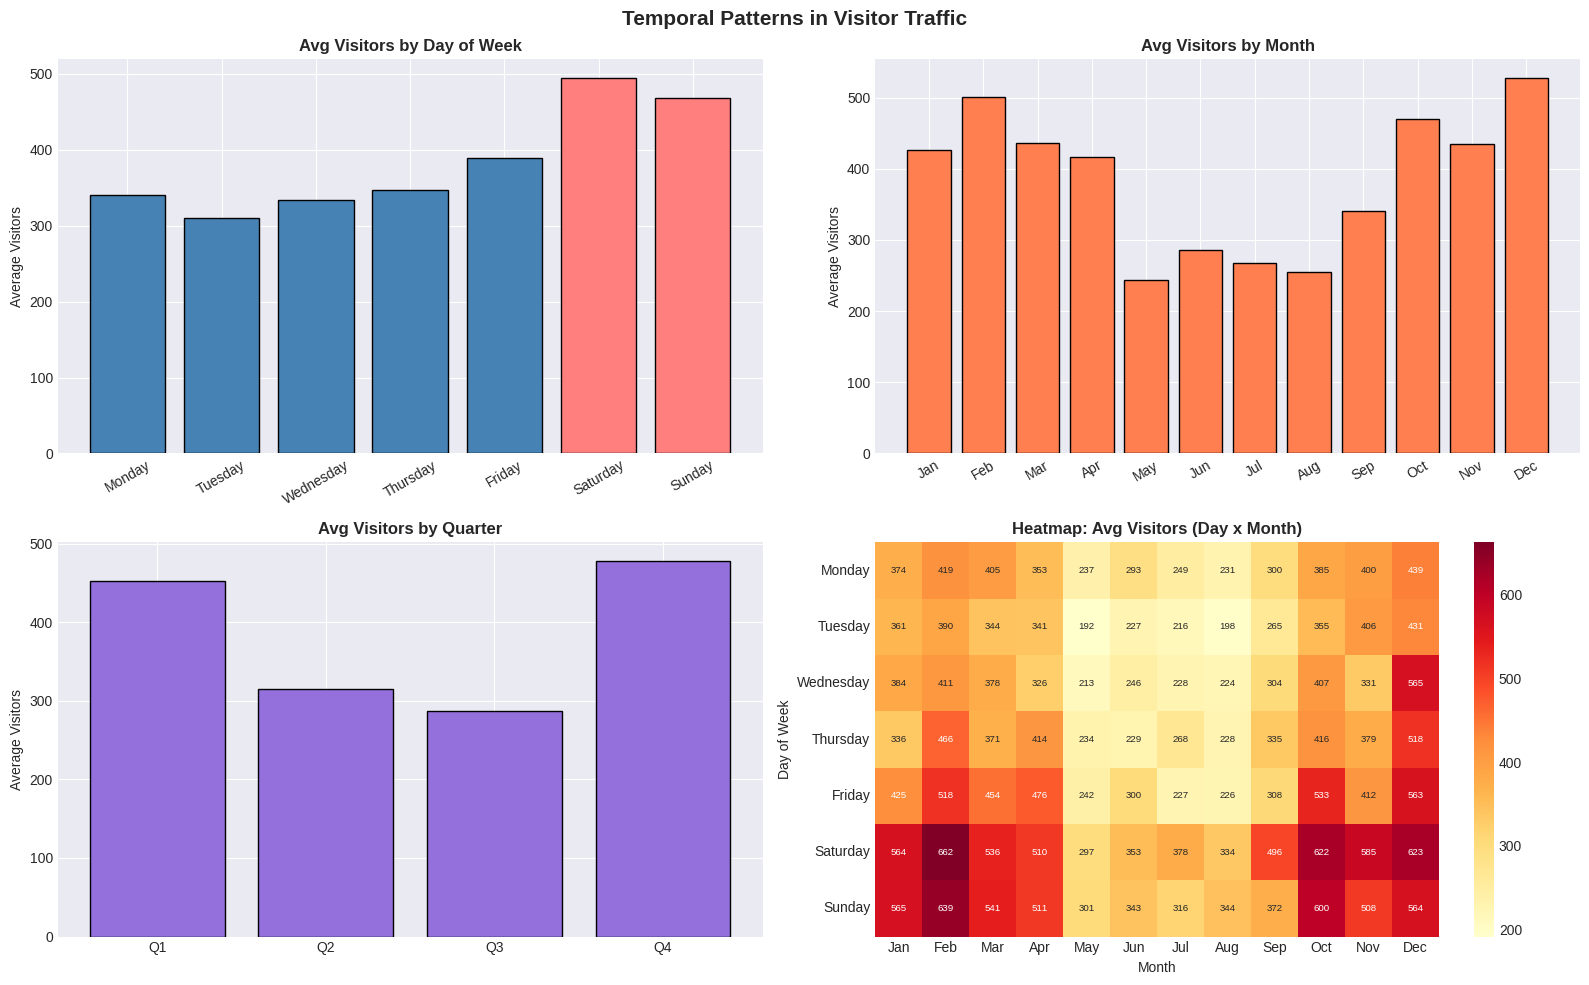

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Day of week
day_avg = df.groupby('day_name')['visitors'].mean().reindex(day_order)
colors = ['#ff7f7f' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in day_order]
axes[0, 0].bar(day_order, day_avg, color=colors, edgecolor='black')
axes[0, 0].set_title('Avg Visitors by Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Average Visitors')
axes[0, 0].tick_params(axis='x', rotation=30)

# Month of year
month_avg = df.groupby('month')['visitors'].mean()
axes[0, 1].bar(range(1, 13), month_avg, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names)
axes[0, 1].set_title('Avg Visitors by Month', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Visitors')
axes[0, 1].tick_params(axis='x', rotation=30)

# Quarter
quarter_avg = df.groupby('quarter')['visitors'].mean()
axes[1, 0].bar([f'Q{q}' for q in quarter_avg.index], quarter_avg, color='mediumpurple', edgecolor='black')
axes[1, 0].set_title('Avg Visitors by Quarter', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Visitors')

# Heatmap: Day of week x Month
heatmap_data = df.pivot_table(values='visitors', index='day_name', columns='month', aggfunc='mean')
heatmap_data = heatmap_data.reindex(day_order)
heatmap_data.columns = month_names
sns.heatmap(heatmap_data, ax=axes[1, 1], cmap='YlOrRd', fmt='.0f',
            annot=True, annot_kws={'size': 7})
axes[1, 1].set_title('Heatmap: Avg Visitors (Day x Month)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Day of Week')

plt.suptitle('Temporal Patterns in Visitor Traffic', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Impact of Key Factors

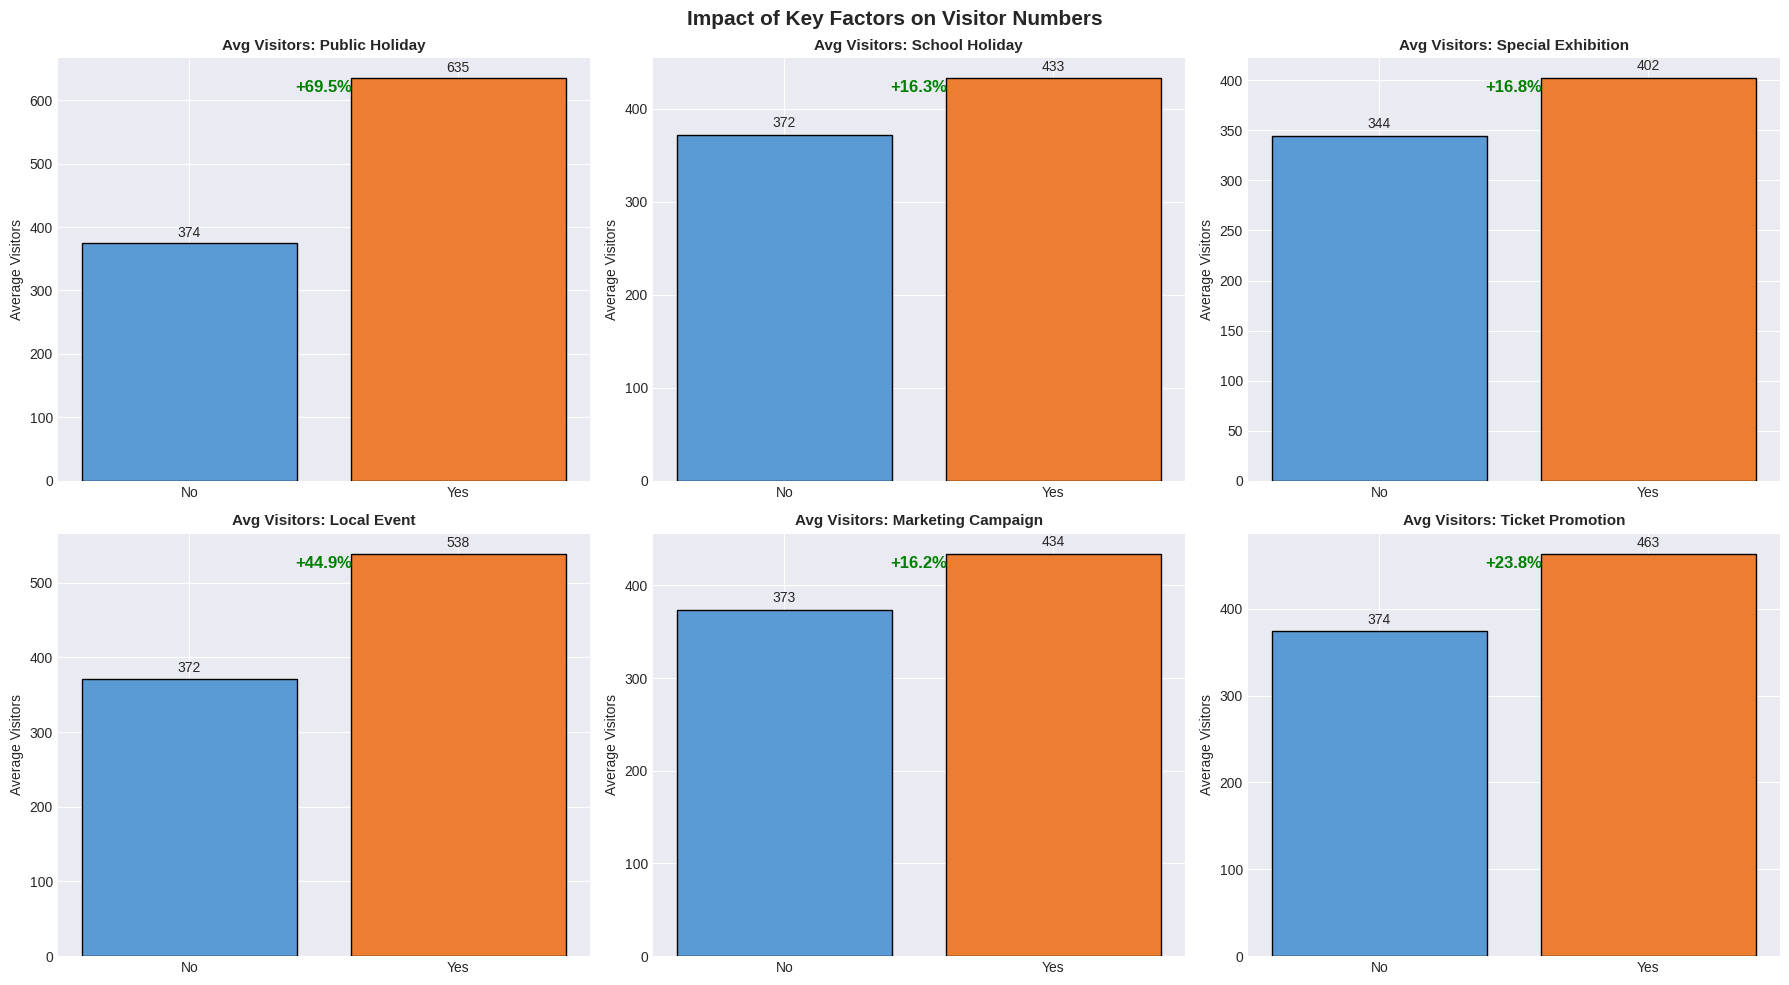

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

binary_features = [
    ('is_public_holiday', 'Public Holiday', ['No', 'Yes']),
    ('is_school_holiday', 'School Holiday', ['No', 'Yes']),
    ('special_exhibition', 'Special Exhibition', ['No', 'Yes']),
    ('local_event', 'Local Event', ['No', 'Yes']),
    ('marketing_campaign', 'Marketing Campaign', ['No', 'Yes']),
    ('ticket_promotion', 'Ticket Promotion', ['No', 'Yes']),
]

for ax, (col, title, labels) in zip(axes.flat, binary_features):
    avgs = df.groupby(col)['visitors'].mean()
    bars = ax.bar(labels, avgs, color=['#5b9bd5', '#ed7d31'], edgecolor='black')
    ax.set_title(f'Avg Visitors: {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Average Visitors')
    if len(avgs) == 2:
        pct = ((avgs.iloc[1] - avgs.iloc[0]) / avgs.iloc[0]) * 100
        ax.text(0.5, 0.92, f'{pct:+.1f}%', transform=ax.transAxes,
                ha='center', fontsize=12, fontweight='bold',
                color='green' if pct > 0 else 'red')
    for bar, val in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Impact of Key Factors on Visitor Numbers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Weather Analysis

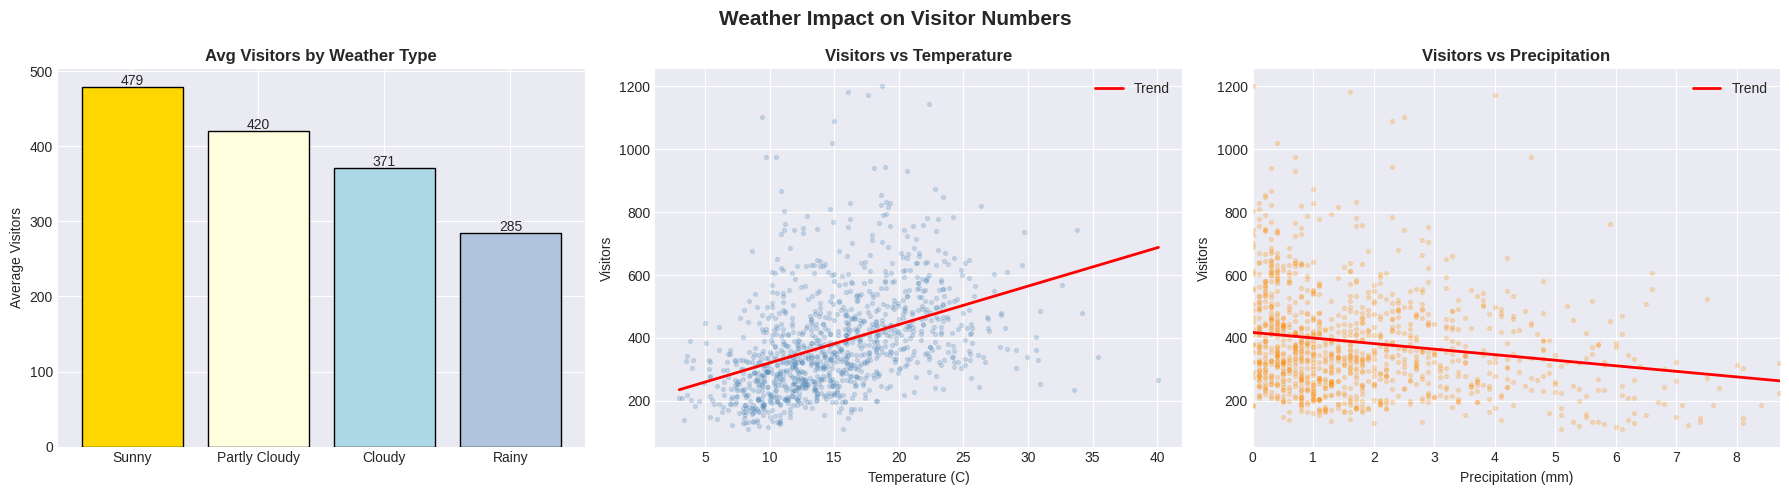

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Weather type
weather_avg = df.groupby('weather_type')['visitors'].mean().sort_values(ascending=False)
axes[0].bar(weather_avg.index, weather_avg,
            color=['gold', 'lightyellow', 'lightblue', 'lightsteelblue'],
            edgecolor='black')
for i, (wt, val) in enumerate(weather_avg.items()):
    axes[0].text(i, val + 3, f'{val:.0f}', ha='center', fontsize=10)
axes[0].set_title('Avg Visitors by Weather Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Visitors')

# Temperature vs visitors
axes[1].scatter(df['temperature'], df['visitors'], alpha=0.2, s=8, color='steelblue')
z = np.polyfit(df['temperature'], df['visitors'], 1)
temp_range = np.linspace(df['temperature'].min(), df['temperature'].max(), 100)
axes[1].plot(temp_range, np.poly1d(z)(temp_range), color='red', linewidth=2, label='Trend')
axes[1].set_title('Visitors vs Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature (C)')
axes[1].set_ylabel('Visitors')
axes[1].legend()

# Precipitation vs visitors
axes[2].scatter(df['precipitation'], df['visitors'], alpha=0.2, s=8, color='darkorange')
z2 = np.polyfit(df['precipitation'], df['visitors'], 1)
prec_range = np.linspace(0, df['precipitation'].quantile(0.99), 100)
axes[2].plot(prec_range, np.poly1d(z2)(prec_range), color='red', linewidth=2, label='Trend')
axes[2].set_xlim(0, df['precipitation'].quantile(0.99))
axes[2].set_title('Visitors vs Precipitation', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Precipitation (mm)')
axes[2].set_ylabel('Visitors')
axes[2].legend()

plt.suptitle('Weather Impact on Visitor Numbers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

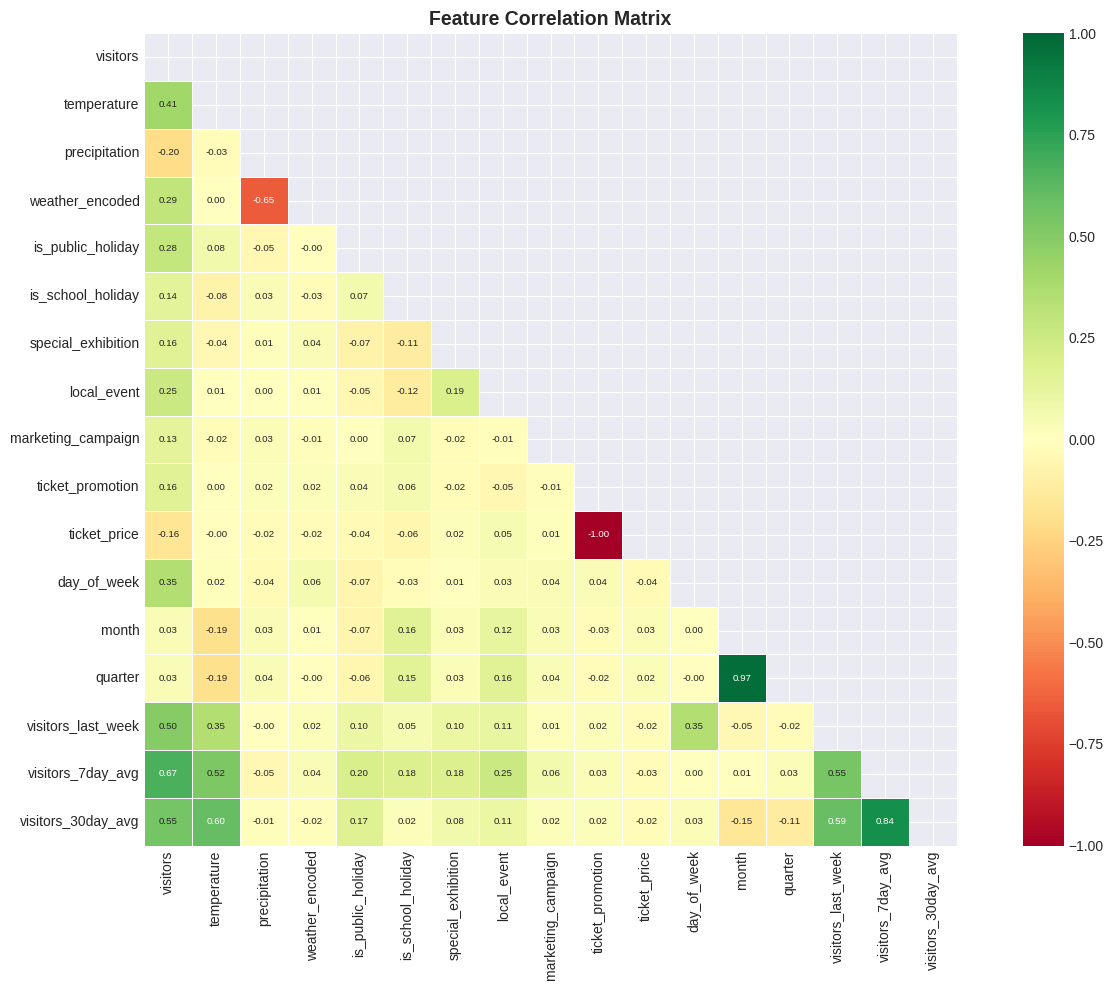


Top correlations with 'visitors':
visitors_7day_avg     0.665
visitors_30day_avg    0.547
visitors_last_week    0.499
temperature           0.409
day_of_week           0.346
weather_encoded       0.289
is_public_holiday     0.284
local_event           0.254
precipitation        -0.204
special_exhibition    0.164
ticket_promotion      0.162
ticket_price         -0.162
is_school_holiday     0.141
marketing_campaign    0.133
month                 0.035
quarter               0.034
Name: visitors, dtype: float64


In [11]:
df_corr = df.copy()
df_corr['weather_encoded'] = df_corr['weather_type'].map(
    {'Sunny': 3, 'Partly Cloudy': 2, 'Cloudy': 1, 'Rainy': 0}
)

numeric_cols = [
    'visitors', 'temperature', 'precipitation', 'weather_encoded',
    'is_public_holiday', 'is_school_holiday', 'special_exhibition',
    'local_event', 'marketing_campaign', 'ticket_promotion', 'ticket_price',
    'day_of_week', 'month', 'quarter',
    'visitors_last_week', 'visitors_7day_avg', 'visitors_30day_avg'
]

corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with 'visitors':")
print(corr_matrix['visitors'].drop('visitors').sort_values(key=abs, ascending=False).round(3))

## 8. Outlier Analysis

IQR bounds: [-38, 766]
Outlier days: 32 (2.9% of data)


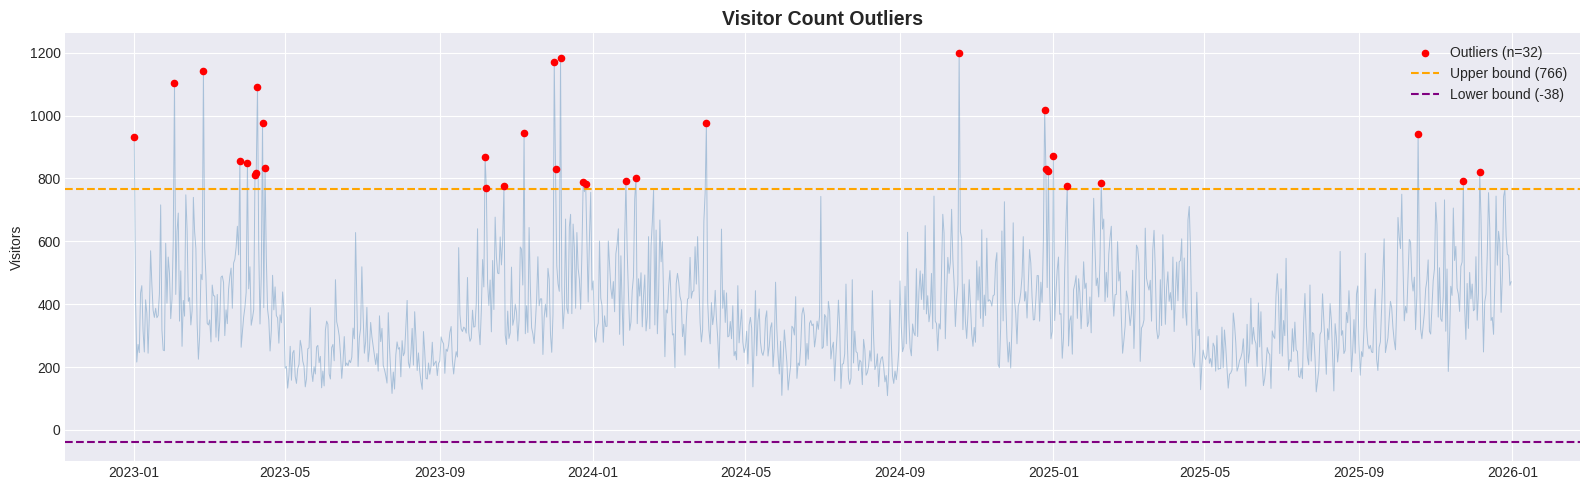


Top 10 highest-traffic days:
      date  visitors  day_name  is_public_holiday  special_exhibition  local_event  weather_type
2024-10-18      1200    Friday                  0                   1            1 Partly Cloudy
2023-12-06      1182 Wednesday                  0                   1            0        Cloudy
2023-12-01      1172    Friday                  0                   1            0        Cloudy
2023-02-25      1143  Saturday                  0                   1            0         Rainy
2023-02-02      1104  Thursday                  0                   1            0        Cloudy
2023-04-09      1090    Sunday                  1                   1            0        Cloudy
2024-12-25      1019 Wednesday                  1                   0            0         Sunny
2023-04-13       975  Thursday                  0                   1            0        Cloudy
2024-03-31       975    Sunday                  1                   1            0        Cloudy


In [12]:
Q1 = df['visitors'].quantile(0.25)
Q3 = df['visitors'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['visitors'] < lower) | (df['visitors'] > upper)]

print(f"IQR bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Outlier days: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")

plt.figure(figsize=(16, 5))
plt.plot(df['date'], df['visitors'], alpha=0.4, linewidth=0.7, color='steelblue')
plt.scatter(outliers['date'], outliers['visitors'], color='red', s=20, zorder=5,
            label=f'Outliers (n={len(outliers)})')
plt.axhline(upper, color='orange', linestyle='--', linewidth=1.5,
            label=f'Upper bound ({upper:.0f})')
plt.axhline(lower, color='purple', linestyle='--', linewidth=1.5,
            label=f'Lower bound ({lower:.0f})')
plt.title('Visitor Count Outliers', fontsize=14, fontweight='bold')
plt.ylabel('Visitors')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 highest-traffic days:")
print(df.nlargest(10, 'visitors')[[
    'date', 'visitors', 'day_name', 'is_public_holiday',
    'special_exhibition', 'local_event', 'weather_type'
]].to_string(index=False))

## 9. Autocorrelation (Time Series Dependence)

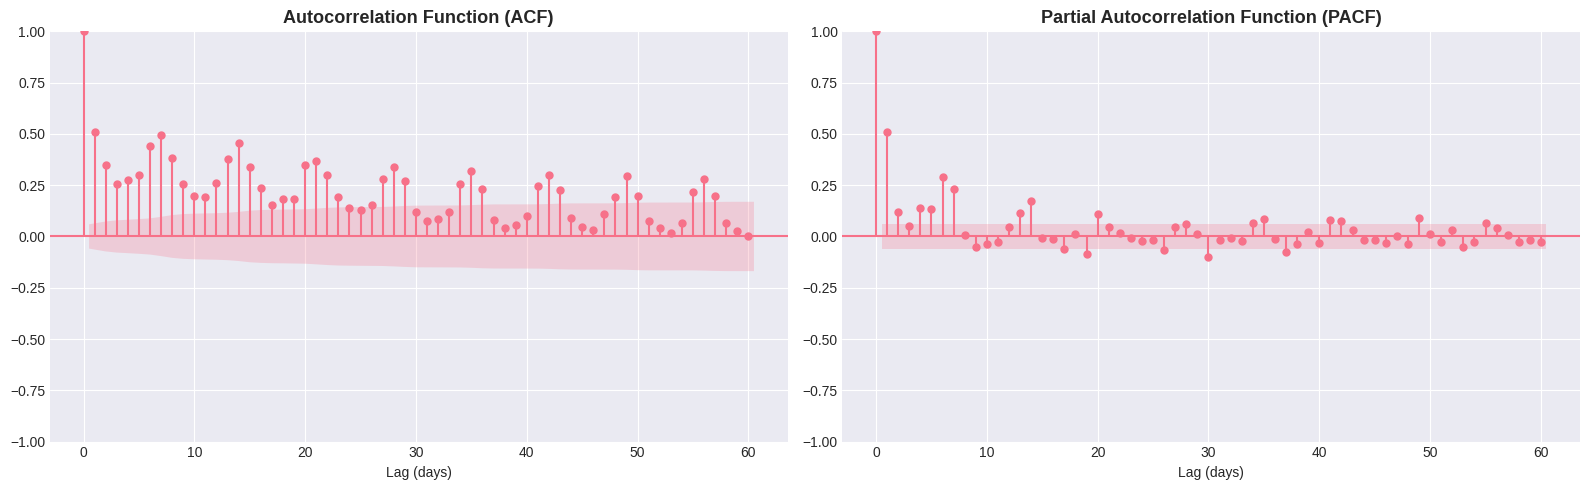

Autocorrelation at key lags:
  Lag   1 days: 0.512
  Lag   7 days: 0.502
  Lag  14 days: 0.465
  Lag  30 days: 0.125
  Lag 365 days: 0.484


In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['visitors'], lags=60, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (days)')

plot_pacf(df['visitors'], lags=60, ax=axes[1], alpha=0.05)
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

print("Autocorrelation at key lags:")
for lag in [1, 7, 14, 30, 365]:
    if lag < len(df):
        corr = df['visitors'].autocorr(lag=lag)
        print(f"  Lag {lag:3d} days: {corr:.3f}")

## 10. EDA Summary & Key Insights

In [14]:
print("=" * 55)
print("EDA SUMMARY - KEY INSIGHTS")
print("=" * 55)

print(f"""
DATASET
  Records : {len(df):,} days ({df['date'].min().date()} to {df['date'].max().date()})
  Visitors: mean={df['visitors'].mean():.0f}, median={df['visitors'].median():.0f},
            min={df['visitors'].min()}, max={df['visitors'].max()}

TEMPORAL PATTERNS
  Busiest day   : {df.groupby('day_name')['visitors'].mean().idxmax()}
  Quietest day  : {df.groupby('day_name')['visitors'].mean().idxmin()}
  Busiest month : {month_names[df.groupby('month')['visitors'].mean().idxmax()-1]}
  Quietest month: {month_names[df.groupby('month')['visitors'].mean().idxmin()-1]}

FACTOR IMPACTS (avg visitor change vs baseline)
  Public holiday : {((df[df['is_public_holiday']==1]['visitors'].mean() / df[df['is_public_holiday']==0]['visitors'].mean())-1)*100:+.1f}%
  School holiday : {((df[df['is_school_holiday']==1]['visitors'].mean() / df[df['is_school_holiday']==0]['visitors'].mean())-1)*100:+.1f}%
  Special exhibit: {((df[df['special_exhibition']==1]['visitors'].mean() / df[df['special_exhibition']==0]['visitors'].mean())-1)*100:+.1f}%
  Local event    : {((df[df['local_event']==1]['visitors'].mean() / df[df['local_event']==0]['visitors'].mean())-1)*100:+.1f}%
  Marketing camp.: {((df[df['marketing_campaign']==1]['visitors'].mean() / df[df['marketing_campaign']==0]['visitors'].mean())-1)*100:+.1f}%

OUTLIERS
  {len(outliers)} days ({len(outliers)/len(df)*100:.1f}%) outside IQR bounds [{lower:.0f}, {upper:.0f}]

MODELLING IMPLICATIONS
  - Strong weekly seasonality  -> include day-of-week features
  - Strong annual seasonality  -> include month/season features
  - Lag-7 autocorrelation high -> lagged features are valuable
  - Weather, holidays, events have measurable impact -> keep all
  - Slight right skew          -> may benefit from log-transform
""")
print("=" * 55)

EDA SUMMARY - KEY INSIGHTS

DATASET
  Records : 1,096 days (2023-01-01 to 2025-12-31)
  Visitors: mean=383, median=348,
            min=109, max=1200

TEMPORAL PATTERNS
  Busiest day   : Saturday
  Quietest day  : Tuesday
  Busiest month : Dec
  Quietest month: May

FACTOR IMPACTS (avg visitor change vs baseline)
  Public holiday : +69.5%
  School holiday : +16.3%
  Special exhibit: +16.8%
  Local event    : +44.9%
  Marketing camp.: +16.2%

OUTLIERS
  32 days (2.9%) outside IQR bounds [-38, 766]

MODELLING IMPLICATIONS
  - Strong weekly seasonality  -> include day-of-week features
  - Strong annual seasonality  -> include month/season features
  - Lag-7 autocorrelation high -> lagged features are valuable
  - Weather, holidays, events have measurable impact -> keep all
  - Slight right skew          -> may benefit from log-transform



## Next Step

**`03_feature_engineering.ipynb`** — Build additional features informed by these insights:
- Cyclical encoding of day/month (sin/cos transforms)
- Interaction features (e.g. weekend x school holiday)
- Log-transform of target variable
- Additional lag/rolling window features